## CAS Applied Data Science Final Project | Rodrigue, Kabir, Sertac

**Research main objective**

This project aims to critically examine the informational requirements for machine learning–based divorce prediction, by evaluating which categories of variables (demographic, socioeconomic, relational, and psychological carry sufficient predictive signal, and identifying the data gaps that limit model performance when only cross-sectional, population-level features are available. 

Specifically, it seeks at 

- Evaluate the limitations of standard multidimensional features (demographic, socioeconomic, and self-reported relational metrics) in accurately predicting marital dissolution.
- Identify which feature domains (if any) contribute the most consistent signal across models, using cross-model feature importance analysis.
- Propose variable types that the divorce prediction literature identifies as truly discriminative.


**Research questions**

- Why do traditional multidimensional determinants yield such modest predictive performance (approximately 60% accuracy) in divorce classification models?
-  Among the features utilized, which specific categories exhibit the highest relative importance, and what does their overall lack of explanatory power reveal about the complexities of divorce?
- What novel types of data are theoretically required to build a genuinely robust predictive model?


**Methods**
-	Exploration of the dataset 
-	Preparation of the dataset
-	Training and comparison of supervised learning models
-	Identification of  the most important predictors of divorce




---
## Section 1 — Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
PRIMARY   = '#1A5276'   # Not divorced → blue
SECONDARY = '#2471A3'
ACCENT    = '#5DADE2'
CORAL     = '#E74C3C'   # Divorced → red/coral
GREEN     = '#1E8449'
AMBER     = '#D4AC0D'
GRAY      = '#717D7E'
LIGHT_BG  = '#F8FBFF'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   LIGHT_BG,
    'axes.edgecolor':   '#D0D8E0',
    'axes.labelcolor':  '#1C2833',
    'xtick.color':      '#1C2833',
    'ytick.color':      '#1C2833',
    'grid.color':       '#DAE4EE',
    'grid.alpha':        0.6,
    'axes.titlesize':    13,
    'axes.titleweight': 'bold',
})

# ── Colour palettes for divorce status ────────────────────────────────────────
palette     = {0: PRIMARY, 1: CORAL}
labels_dict = {0: 'Not divorced', 1: 'Divorced'}

print("Libraries loaded. Ready to begin EDA.")


Libraries loaded. Ready to begin EDA.


---
## Section 2 — Data Loading and First Inspection

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Adjust the path if running from a different directory
df = pd.read_csv('divorce_df.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.head()


Dataset shape: 5,000 rows × 22 columns



,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,1,6.212046,3,...,0,0,0,5.263555,5,Love,1,0,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1


In [3]:
# Last 5 rows — check consistency at the tail
df.tail()


,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
4995,27,1,3,Master,Full-time,67410,Same Religion,1,7.406795,1,...,0,0,0,4.071359,4,Arranged,1,0,6.333963,0
4996,31,21,2,Bachelor,Homemaker,88995,Same Religion,1,3.971897,2,...,0,1,1,3.064645,3,Love,1,0,3.279566,0
4997,43,13,2,Bachelor,Homemaker,93184,Same Religion,0,10.000000,4,...,1,0,0,7.728128,3,Other,0,0,4.002068,1
4998,32,1,2,Master,Part-time,54132,Same Religion,1,3.382175,2,...,0,0,0,8.827352,3,Arranged,1,0,3.790967,0
4999,23,8,2,Bachelor,Full-time,38412,Different Religion,1,5.471466,2,...,0,0,0,4.609792,6,Love,1,0,5.163251,0


In [4]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_at_marriage            5000 non-null   int64  
 1   marriage_duration_years    5000 non-null   int64  
 2   num_children               5000 non-null   int64  
 3   education_level            5000 non-null   object 
 4   employment_status          5000 non-null   object 
 5   combined_income            5000 non-null   int64  
 6   religious_compatibility    5000 non-null   object 
 7   cultural_background_match  5000 non-null   int64  
 8   communication_score        5000 non-null   float64
 9   conflict_frequency         5000 non-null   int64  
 10  conflict_resolution_style  5000 non-null   object 
 11  financial_stress_level     5000 non-null   float64
 12  mental_health_issues       5000 non-null   int64  
 13  infidelity_occurred        5000 non-null   int64

---
## Section 3 — Dataset Structure and Feature Types

In [5]:
# ── Feature classification ────────────────────────────────────────────────────
num_continuous = [
    'age_at_marriage', 'marriage_duration_years', 'combined_income',
    'communication_score', 'financial_stress_level',
    'social_support', 'trust_score',
]

num_discrete = [
    'num_children', 'conflict_frequency', 'shared_hobbies_count',
]

num_all = num_continuous + num_discrete   # all 10 numeric features

cat_multi = [
    'education_level', 'employment_status', 'religious_compatibility',
    'conflict_resolution_style', 'marriage_type',
]

cat_binary = [
    'cultural_background_match', 'mental_health_issues', 'infidelity_occurred',
    'counseling_attended', 'pre_marital_cohabitation', 'domestic_violence_history',
]

target = 'divorced'

# ── Summary ───────────────────────────────────────────────────────────────────
print("Feature inventory")
print(f"  Numeric continuous  : {len(num_continuous):>2} — {num_continuous}")
print(f"  Numeric discrete    : {len(num_discrete):>2} — {num_discrete}")
print(f"  Multi-level categ.  : {len(cat_multi):>2} — {cat_multi}")
print(f"  Binary              : {len(cat_binary):>2} — {cat_binary}")
print(f"  Target              :  1 — {target}")
print(f"  TOTAL               : {len(num_all)+len(cat_multi)+len(cat_binary)+1}")


Feature inventory
  Numeric continuous  :  7 — ['age_at_marriage', 'marriage_duration_years', 'combined_income', 'communication_score', 'financial_stress_level', 'social_support', 'trust_score']
  Numeric discrete    :  3 — ['num_children', 'conflict_frequency', 'shared_hobbies_count']
  Multi-level categ.  :  5 — ['education_level', 'employment_status', 'religious_compatibility', 'conflict_resolution_style', 'marriage_type']
  Binary              :  6 — ['cultural_background_match', 'mental_health_issues', 'infidelity_occurred', 'counseling_attended', 'pre_marital_cohabitation', 'domestic_violence_history']
  Target              :  1 — divorced
  TOTAL               : 22


In [6]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "  ✓  No missing values detected.")
print(f"\nTotal missing cells: {missing.sum()}")


Missing values per column:
  ✓  No missing values detected.

Total missing cells: 0


---
## Section 4 — Class Balance (Target Variable)

In [7]:
# ── Class counts and rates ────────────────────────────────────────────────────
vc = df[target].value_counts()
rates = df[target].value_counts(normalize=True) * 100

balance = pd.DataFrame({
    'Count':      vc,
    'Percentage': rates.round(2)
})
balance.index = ['Not divorced (0)', 'Divorced (1)']
print(balance.to_string())
print(f"\nImbalance ratio (majority / minority): {vc[0]/vc[1]:.2f}")


                  Count  Percentage
Not divorced (0)   3009       60.18
Divorced (1)       1991       39.82

Imbalance ratio (majority / minority): 1.51


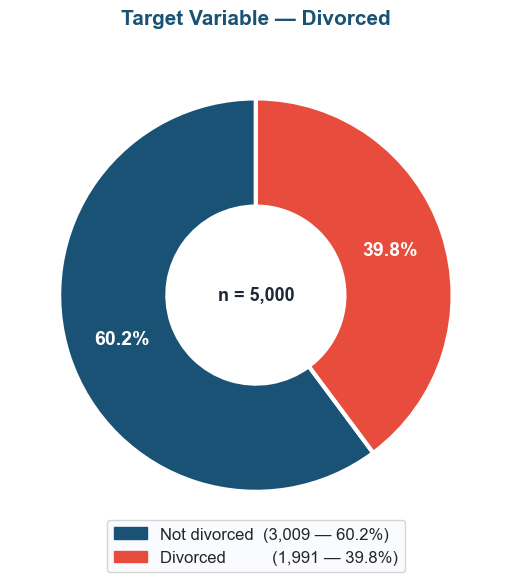

In [8]:
# ── Donut chart ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    [vc[0], vc[1]],
    colors=[PRIMARY, CORAL],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
)
for at in autotexts:
    at.set_fontsize(14); at.set_fontweight('bold'); at.set_color('white')

ax.text(0, 0, f'n = {len(df):,}', ha='center', va='center',
        fontsize=13, color='#1C2833', fontweight='bold')
ax.set_title('Target Variable — Divorced', fontsize=15, fontweight='bold',
             color=PRIMARY, pad=18)

legend_handles = [
    Patch(color=PRIMARY, label=f'Not divorced  ({vc[0]:,} — {vc[0]/len(df)*100:.1f}%)'),
    Patch(color=CORAL,   label=f'Divorced          ({vc[1]:,} — {vc[1]/len(df)*100:.1f}%)'),
]
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=12)
plt.tight_layout()
plt.savefig('fig_target_balance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 5 — Descriptive Statistics — Numeric Features


In [9]:
# ── Summary statistics ────────────────────────────────────────────────────────
desc = df[num_all].describe().T.round(3)
desc['skewness'] = df[num_all].skew().round(3)
desc['kurtosis'] = df[num_all].kurt().round(3)

# Display selected columns
display_cols = ['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']
print(desc[display_cols].to_string())


                              mean        std      min        25%        50%        75%       max  skewness  kurtosis
age_at_marriage             27.584      4.856     18.0     24.000     28.000     31.000      45.0     0.137    -0.264
marriage_duration_years      9.171      8.848      1.0      2.000      6.000     13.000      40.0     1.461     1.783
combined_income          60220.078  19662.081  10000.0  46666.000  60196.000  73666.500  126909.0     0.000    -0.180
communication_score          6.041      1.963      1.0      4.662      6.058      7.427      10.0    -0.111    -0.423
financial_stress_level       5.071      2.326      1.0      3.366      5.062      6.718      10.0     0.105    -0.690
social_support               5.967      1.966      1.0      4.597      6.011      7.329      10.0    -0.091    -0.372
trust_score                  6.031      1.933      1.0      4.703      6.034      7.373      10.0    -0.074    -0.387
num_children                 1.553      1.248      0.0  

In [10]:
# ── Group means by divorce status ─────────────────────────────────────────────
# A useful first signal check: are any feature means appreciably different?
group_means = df.groupby(target)[num_all].mean().T.round(3)
group_means.columns = ['Mean (not divorced)', 'Mean (divorced)']
group_means['Difference'] = (group_means['Mean (divorced)'] - group_means['Mean (not divorced)']).round(3)
group_means['Diff (%)'] = ((group_means['Difference'] / group_means['Mean (not divorced)']) * 100).round(2)

print("Group means by divorce status:")
print(group_means.to_string())


Group means by divorce status:
                         Mean (not divorced)  Mean (divorced)  Difference  Diff (%)
age_at_marriage                       27.554           27.628       0.074      0.27
marriage_duration_years                9.098            9.281       0.183      2.01
combined_income                    60029.539        60508.041     478.502      0.80
communication_score                    6.161            5.859      -0.302     -4.90
financial_stress_level                 4.938            5.273       0.335      6.78
social_support                         6.021            5.885      -0.136     -2.26
trust_score                            6.110            5.911      -0.199     -3.26
num_children                           1.558            1.545      -0.013     -0.83
conflict_frequency                     1.996            2.027       0.031      1.55
shared_hobbies_count                   2.996            2.937      -0.059     -1.97


---
## Section 6 — Frequency Tables — Categorical and Binary Features


In [11]:
# ── Multi-level categorical variables ─────────────────────────────────────────
print("=" * 65)
for col in cat_multi:
    ct = pd.crosstab(df[col], df[target])
    ct.columns = ['Not divorced', 'Divorced']
    ct['Total']       = ct.sum(axis=1)
    ct['Divorce rate (%)'] = (ct['Divorced'] / ct['Total'] * 100).round(1)
    ct = ct.sort_values('Divorce rate (%)', ascending=False)
    print(f"\n{col.replace('_', ' ').title()}")
    print(ct.to_string())
    print("-" * 65)



Education Level
                     Not divorced  Divorced  Total  Divorce rate (%)
education_level                                                     
PhD                           122       102    224              45.5
Master                        561       402    963              41.7
High School                   908       605   1513              40.0
Bachelor                     1267       802   2069              38.8
No Formal Education           151        80    231              34.6
-----------------------------------------------------------------

Employment Status
                   Not divorced  Divorced  Total  Divorce rate (%)
employment_status                                                 
Unemployed                  433       304    737              41.2
Homemaker                   443       305    748              40.8
Full-time                  1496       991   2487              39.8
Part-time                   637       391   1028              38.0
-------------

In [12]:
# ── Binary variables ──────────────────────────────────────────────────────────
print("Binary variable summary (0 = No, 1 = Yes)")
print("=" * 60)

rows = []
for col in cat_binary:
    n_yes   = df[col].sum()
    n_no    = len(df) - n_yes
    dr_yes  = df[df[col]==1][target].mean() * 100
    dr_no   = df[df[col]==0][target].mean() * 100
    rows.append({
        'Variable':        col.replace('_',' ').title(),
        'N (No)':          n_no,
        'N (Yes)':         n_yes,
        'Prevalence (%)':  round(n_yes/len(df)*100, 1),
        'Divorce rate No (%)':  round(dr_no, 1),
        'Divorce rate Yes (%)': round(dr_yes, 1),
        'Difference':           round(dr_yes - dr_no, 1),
    })

binary_summary = pd.DataFrame(rows).set_index('Variable')
print(binary_summary.to_string())


Binary variable summary (0 = No, 1 = Yes)
                           N (No)  N (Yes)  Prevalence (%)  Divorce rate No (%)  Divorce rate Yes (%)  Difference
Variable                                                                                                         
Cultural Background Match    1223     3777            75.5                 40.7                  39.5        -1.2
Mental Health Issues         3981     1019            20.4                 38.9                  43.5         4.6
Infidelity Occurred          4255      745            14.9                 38.3                  48.6        10.3
Counseling Attended          3798     1202            24.0                 39.6                  40.6         1.0
Pre Marital Cohabitation     2039     2961            59.2                 41.3                  38.8        -2.5
Domestic Violence History    4748      252             5.0                 38.9                  56.7        17.8


---
## Section 7 — Univariate Distributions — Numeric Features

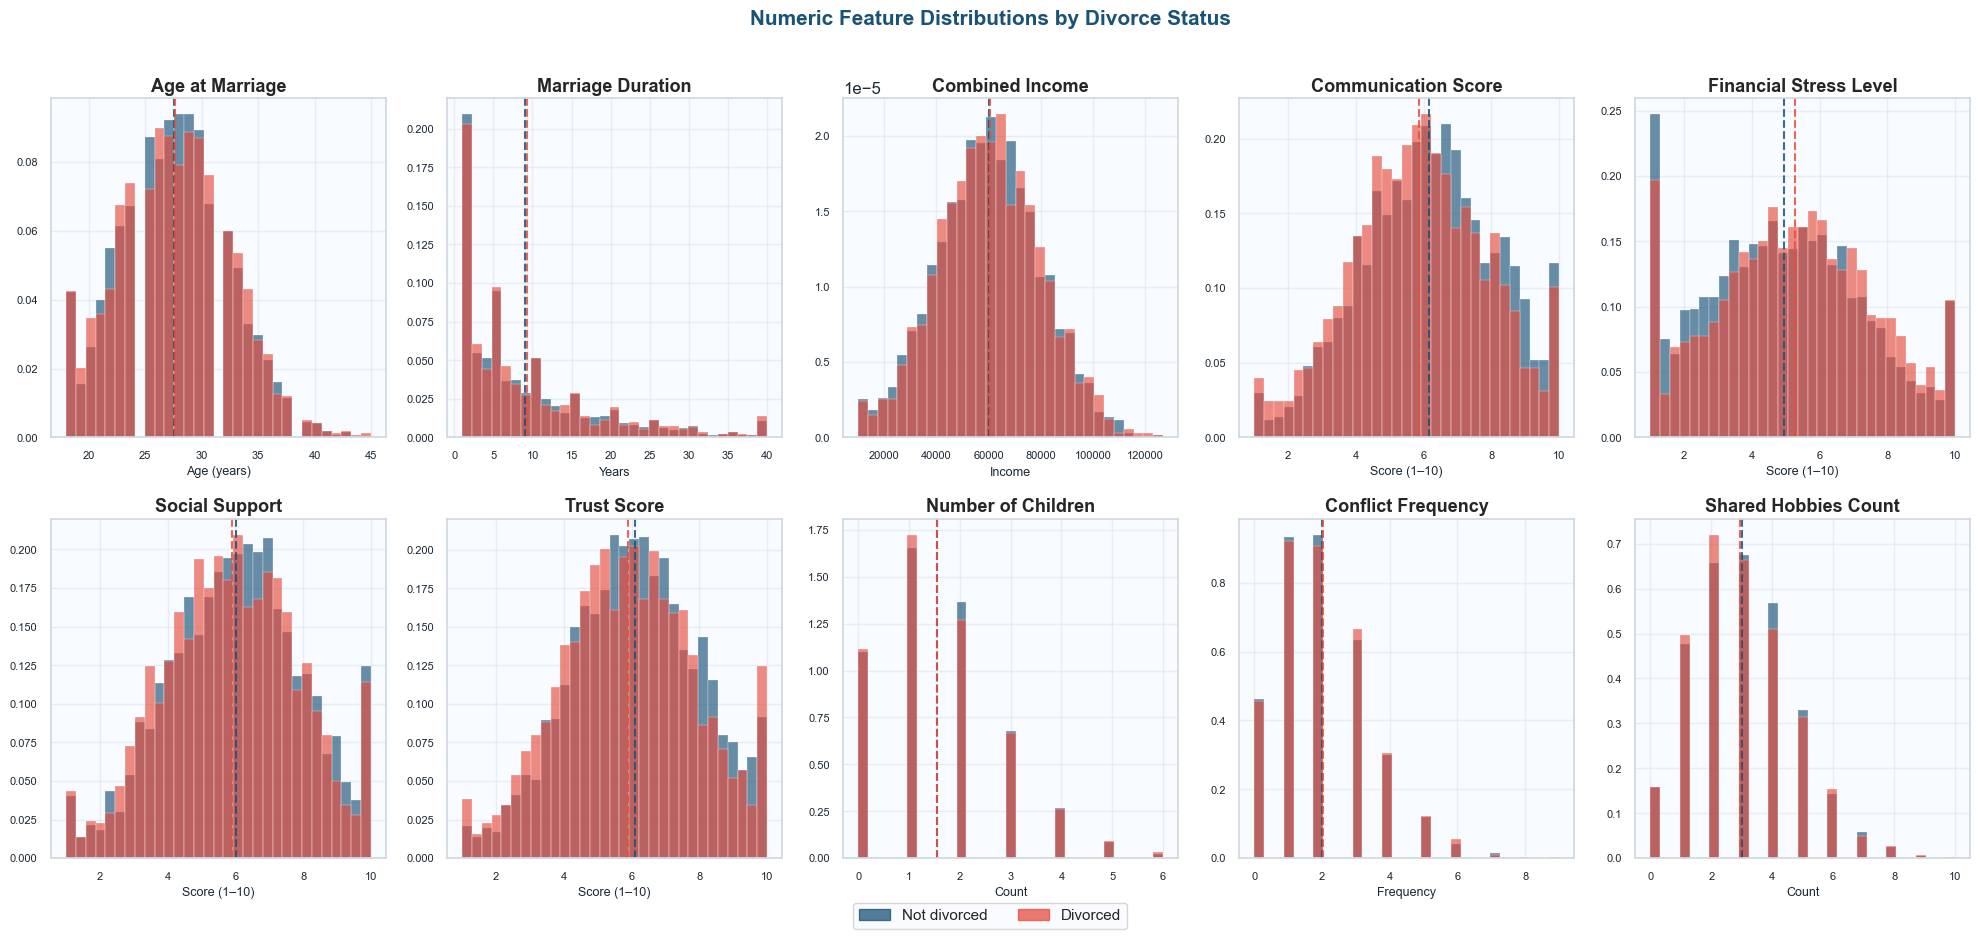

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Numeric Feature Distributions by Divorce Status',
             fontsize=15, fontweight='bold', color=PRIMARY, y=1.01)

col_labels = {
    'age_at_marriage':         ('Age at Marriage', 'Age (years)'),
    'marriage_duration_years': ('Marriage Duration', 'Years'),
    'num_children':            ('Number of Children', 'Count'),
    'combined_income':         ('Combined Income', 'Income'),
    'communication_score':     ('Communication Score', 'Score (1–10)'),
    'conflict_frequency':      ('Conflict Frequency', 'Frequency'),
    'financial_stress_level':  ('Financial Stress Level', 'Score (1–10)'),
    'social_support':          ('Social Support', 'Score (1–10)'),
    'shared_hobbies_count':    ('Shared Hobbies Count', 'Count'),
    'trust_score':             ('Trust Score', 'Score (1–10)'),
}

for ax, col in zip(axes.flatten(), num_all):
    title, xlabel = col_labels[col]
    bins = np.linspace(df[col].min(), df[col].max(), 32)

    for val in [0, 1]:
        subset = df[df[target] == val][col]
        ax.hist(subset, bins=bins, alpha=0.65, color=palette[val],
                label=labels_dict[val], edgecolor='white', linewidth=0.3, density=True)
        ax.axvline(subset.mean(), color=palette[val],
                   linestyle='--', linewidth=1.5, alpha=0.85)

    ax.set_title(title, pad=5)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.tick_params(labelsize=8)

# Single shared legend
legend_handles = [Patch(color=PRIMARY, alpha=0.75, label='Not divorced'),
                  Patch(color=CORAL,   alpha=0.75, label='Divorced')]
fig.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=11)

plt.tight_layout()
plt.savefig('fig_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 8 — Categorical Features by Divorce Status


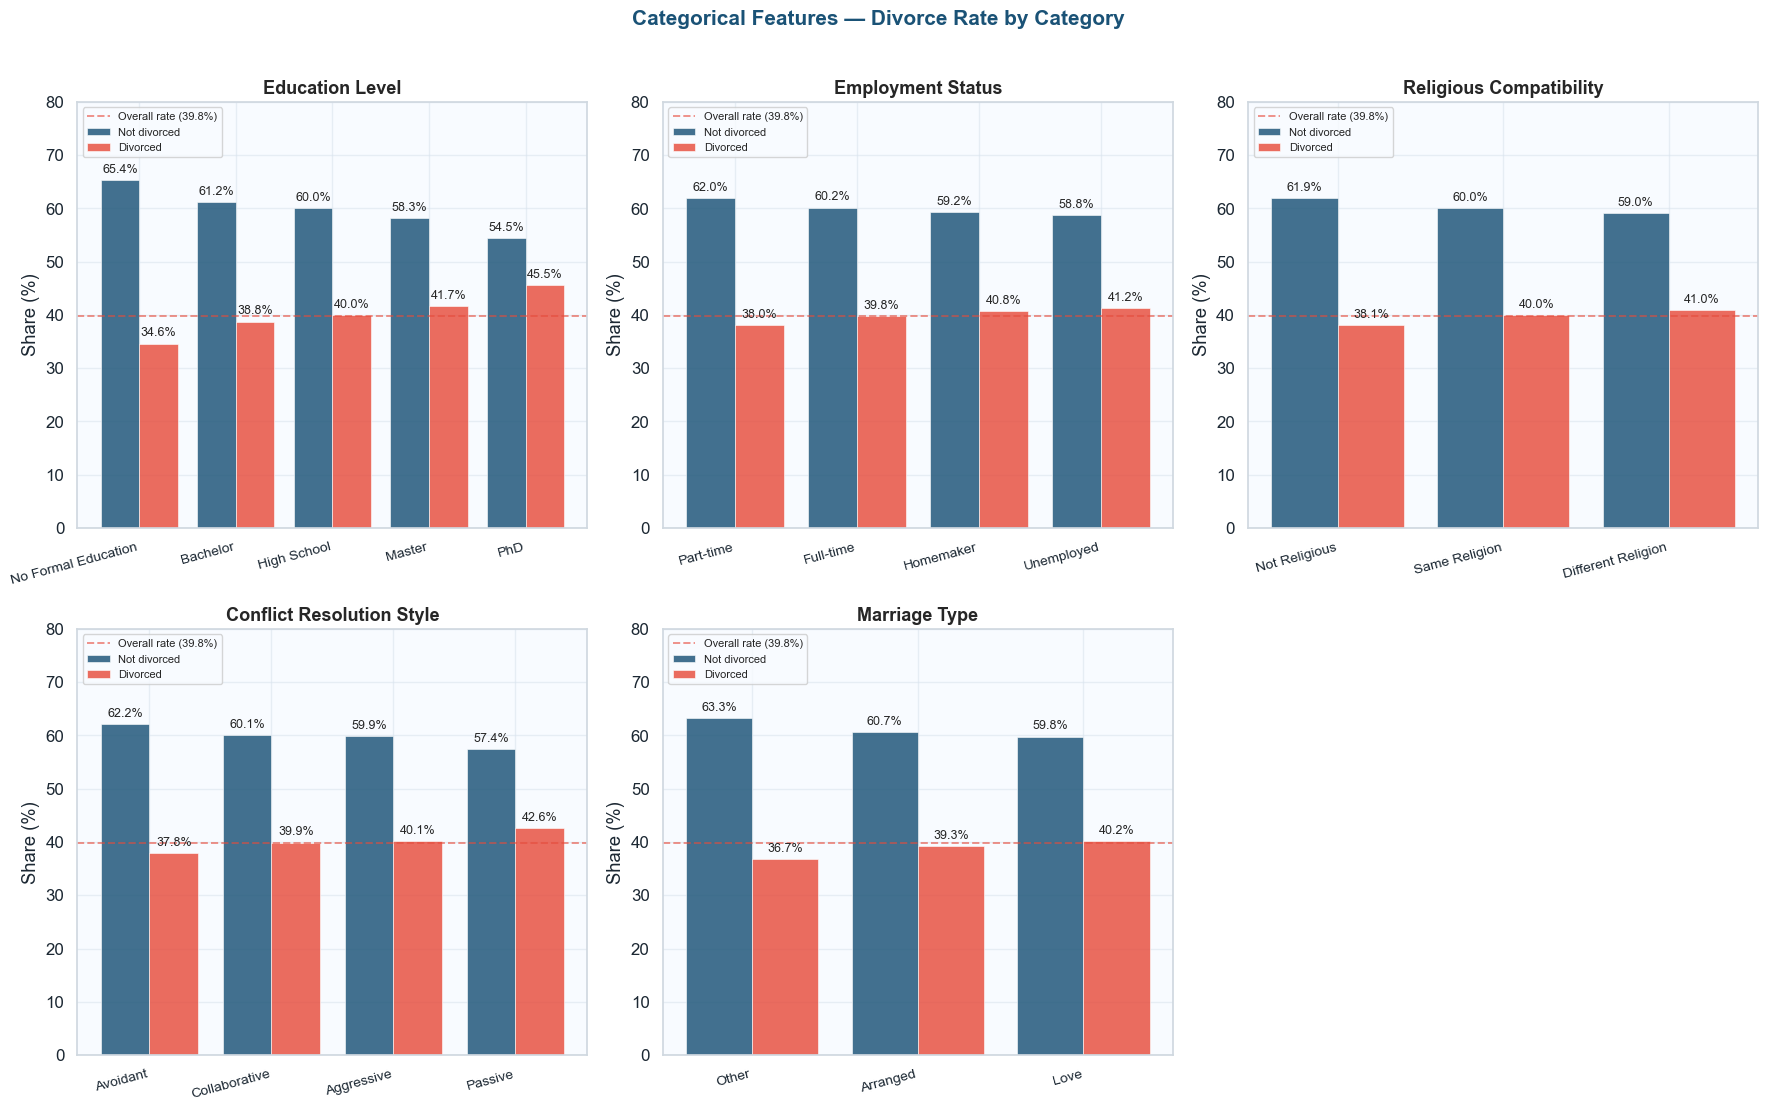

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Categorical Features — Divorce Rate by Category',
             fontsize=15, fontweight='bold', color=PRIMARY, y=1.01)

for ax, col in zip(axes.flatten(), cat_multi):
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct.columns = ['Not divorced', 'Divorced']
    ct = ct.sort_values('Divorced', ascending=True)

    x     = np.arange(len(ct))
    width = 0.4
    b0 = ax.bar(x - width/2, ct['Not divorced'], width, color=PRIMARY,
                alpha=0.82, edgecolor='white', linewidth=0.5, label='Not divorced')
    b1 = ax.bar(x + width/2, ct['Divorced'],     width, color=CORAL,
                alpha=0.82, edgecolor='white', linewidth=0.5, label='Divorced')

    for bar in list(b0) + list(b1):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)

    ax.axhline(df[target].mean()*100, color=CORAL, linestyle='--', linewidth=1.4,
               alpha=0.6, label=f'Overall rate ({df[target].mean()*100:.1f}%)')
    ax.set_xticks(x)
    ax.set_xticklabels(ct.index, fontsize=10, rotation=15, ha='right')
    ax.set_ylabel('Share (%)')
    ax.set_ylim(0, 80)
    ax.set_title(col.replace('_', ' ').title(), pad=6)
    ax.legend(fontsize=8, loc='upper left')

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.savefig('fig_categorical_by_divorce.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 9 — Correlation Analysis


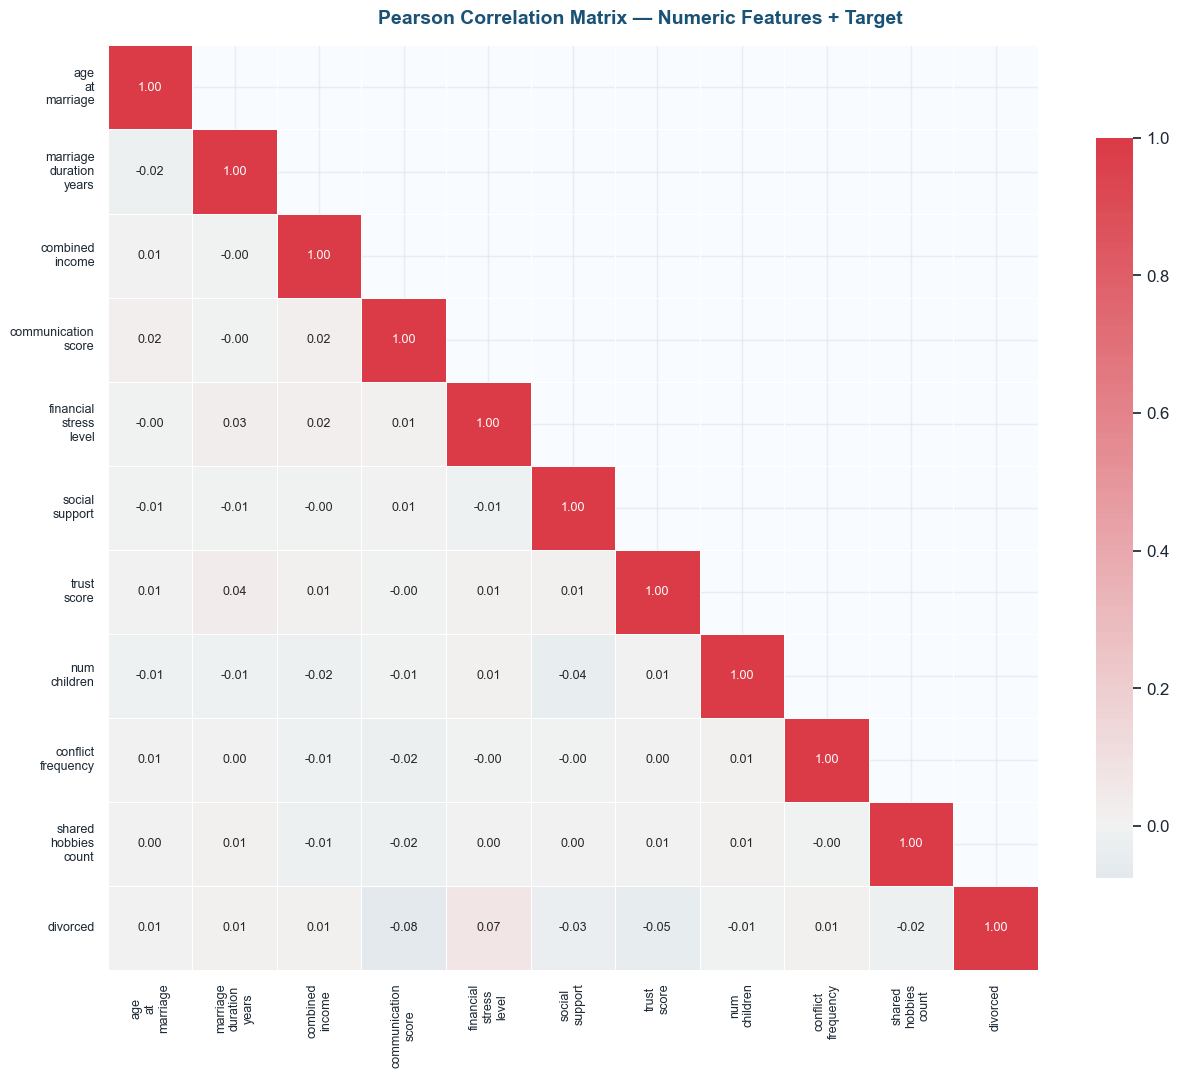

In [15]:
# ── Pearson correlations — numeric features ───────────────────────────────────
corr_matrix = df[num_all + [target]].corr()

fig, ax = plt.subplots(figsize=(13, 11))
fig.suptitle('Pearson Correlation Matrix — Numeric Features + Target',
             fontsize=14, fontweight='bold', color=PRIMARY)

mask  = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap  = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8},
    xticklabels=[c.replace('_', '\n') for c in corr_matrix.columns],
    yticklabels=[c.replace('_', '\n') for c in corr_matrix.columns],
    ax=ax,
)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# ── Feature–target correlations ranked ────────────────────────────────────────
target_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False)

print("Feature–target Pearson |r| ranked:")
for feat, val in target_corr.items():
    bar = '█' * int(val * 40)
    print(f"  {feat:<28} {val:.4f}  {bar}")


Feature–target Pearson |r| ranked:
  communication_score          0.0752  ███
  financial_stress_level       0.0705  ██
  trust_score                  0.0503  ██
  social_support               0.0337  █
  shared_hobbies_count         0.0168  
  combined_income              0.0119  
  conflict_frequency           0.0107  
  marriage_duration_years      0.0101  
  age_at_marriage              0.0075  
  num_children                 0.0051  


In [17]:
# ── Point-biserial: binary features vs target ─────────────────────────────────
from scipy.stats import pointbiserialr

print("Point-biserial correlations — binary features vs divorced:")
print("-" * 55)
for col in cat_binary:
    r_val, p_val = pointbiserialr(df[col], df[target])
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f"  {col:<32}  r = {r_val:+.4f}   p = {p_val:.4f}  {sig}")


Point-biserial correlations — binary features vs divorced:
-------------------------------------------------------
  cultural_background_match         r = -0.0105   p = 0.4598  ns
  mental_health_issues              r = +0.0378   p = 0.0076  **
  infidelity_occurred               r = +0.0750   p = 0.0000  ***
  counseling_attended               r = +0.0090   p = 0.5268  ns
  pre_marital_cohabitation          r = -0.0250   p = 0.0771  ns
  domestic_violence_history         r = +0.0797   p = 0.0000  ***


---
## Section 10 — Box Plots by Divorce Status

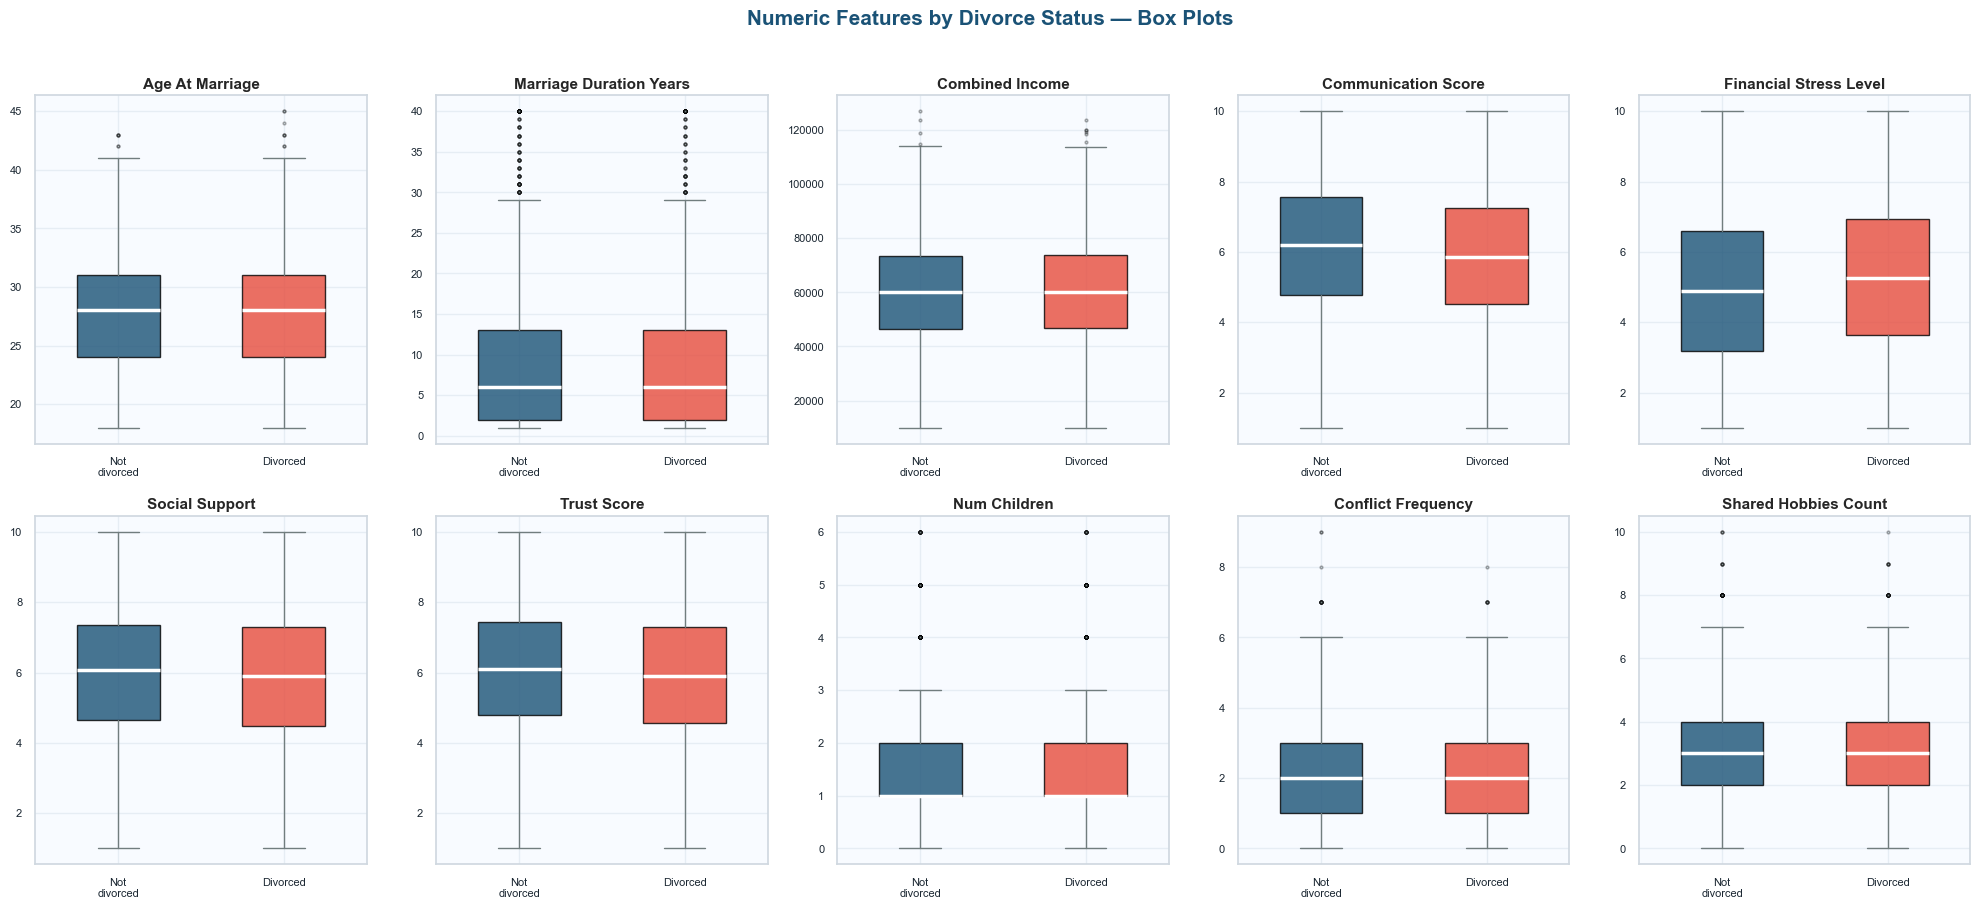

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Numeric Features by Divorce Status — Box Plots',
             fontsize=15, fontweight='bold', color=PRIMARY, y=1.01)

for ax, col in zip(axes.flatten(), num_all):
    title = col.replace('_', ' ').title()
    data_groups = [df[df[target]==0][col].dropna(),
                   df[df[target]==1][col].dropna()]

    bp = ax.boxplot(data_groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color=GRAY),
                    capprops=dict(color=GRAY),
                    flierprops=dict(marker='o', markerfacecolor=GRAY,
                                   markersize=2, alpha=0.3, linestyle='none'))
    bp['boxes'][0].set_facecolor(PRIMARY); bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor(CORAL);   bp['boxes'][1].set_alpha(0.8)

    ax.set_xticklabels(['Not\ndivorced', 'Divorced'], fontsize=9)
    ax.set_title(title, pad=5, fontsize=11)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 11 — Density Distributions — Key Relational Variables

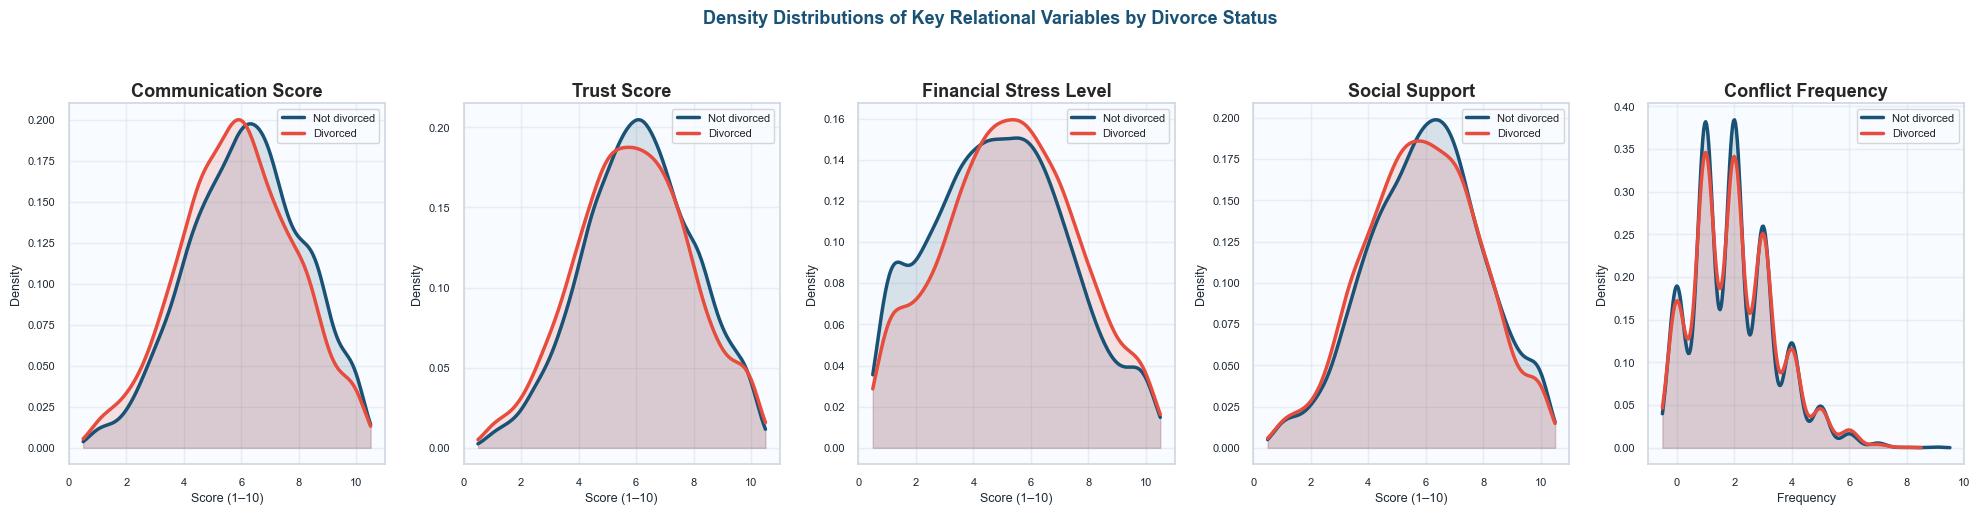

In [19]:
from scipy.stats import gaussian_kde

key_vars = [
    ('communication_score',    'Communication Score',    'Score (1–10)'),
    ('trust_score',            'Trust Score',            'Score (1–10)'),
    ('financial_stress_level', 'Financial Stress Level', 'Score (1–10)'),
    ('social_support',         'Social Support',         'Score (1–10)'),
    ('conflict_frequency',     'Conflict Frequency',     'Frequency'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Density Distributions of Key Relational Variables by Divorce Status',
             fontsize=13, fontweight='bold', color=PRIMARY, y=1.03)

for ax, (col, title, xlabel) in zip(axes, key_vars):
    for val, color, lbl in [(0, PRIMARY, 'Not divorced'), (1, CORAL, 'Divorced')]:
        vals  = df[df[target]==val][col].dropna().values
        x_rng = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde   = gaussian_kde(vals)
        y_kde = kde(x_rng)
        ax.plot(x_rng, y_kde, color=color, linewidth=2.5, label=lbl)
        ax.fill_between(x_rng, y_kde, alpha=0.15, color=color)

    ax.set_title(title, pad=5)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('fig_kde_relational.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 12 — Pairplot — Key Relational Variables


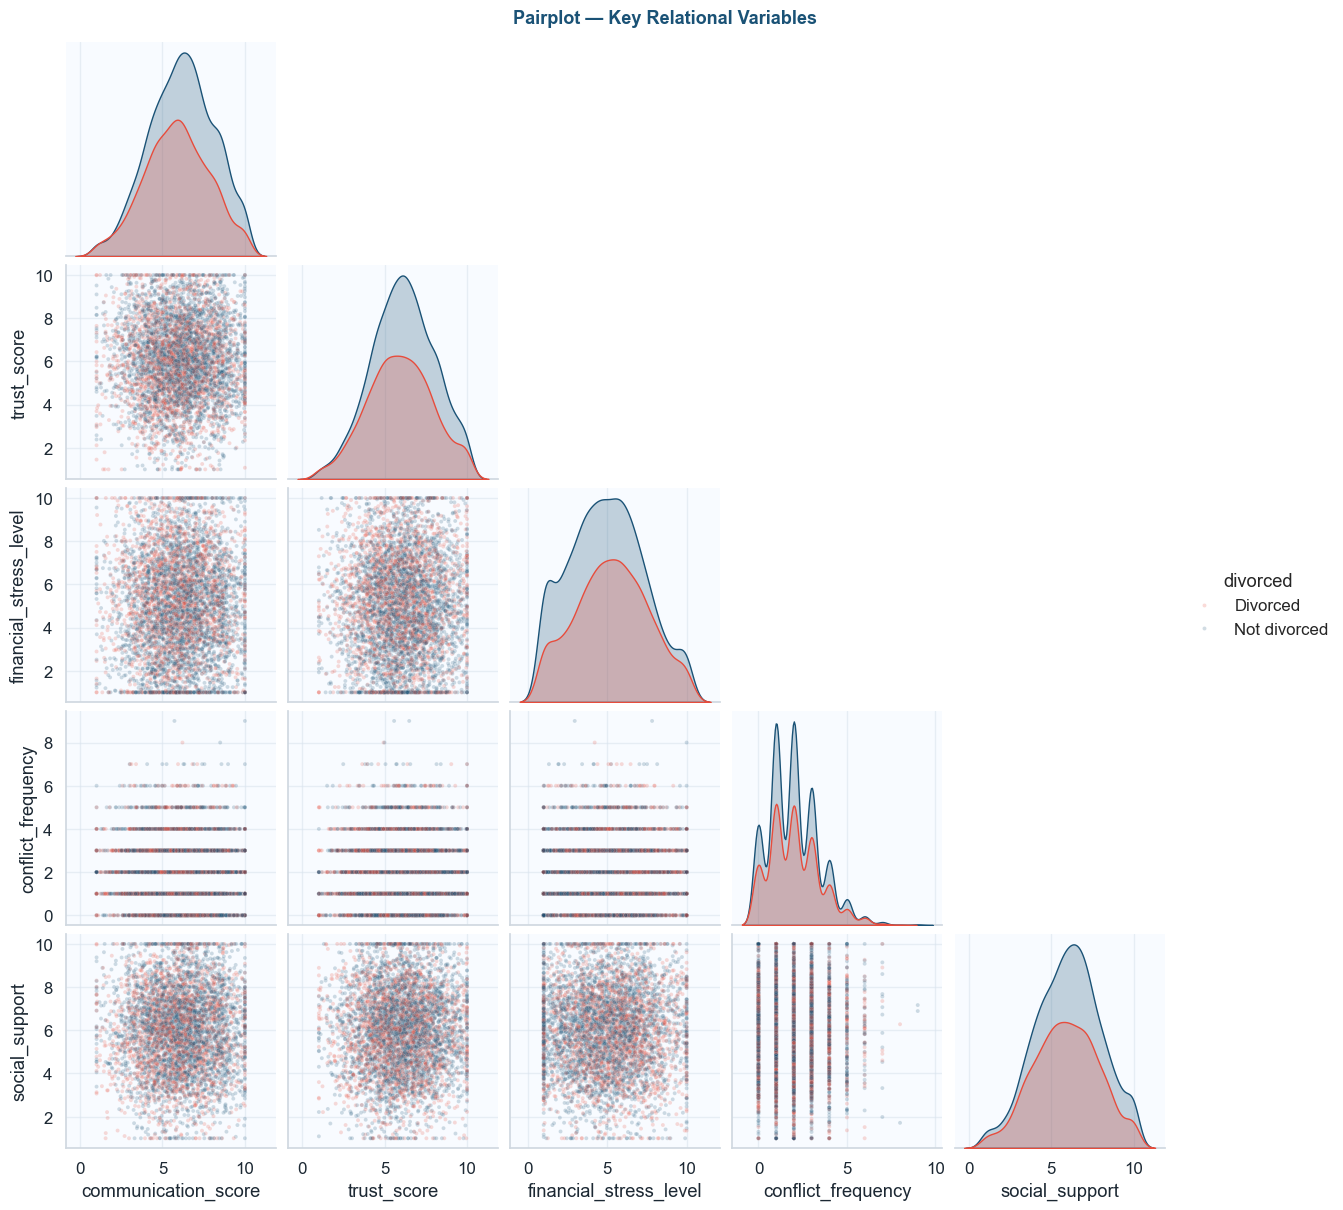

In [20]:
pair_vars = ['communication_score', 'trust_score', 'financial_stress_level',
             'conflict_frequency', 'social_support', target]

df_pair = df[pair_vars].copy()
df_pair[target] = df_pair[target].map({0: 'Not divorced', 1: 'Divorced'})

g = sns.pairplot(
    df_pair,
    hue=target,
    palette={'Not divorced': PRIMARY, 'Divorced': CORAL},
    diag_kind='kde',
    plot_kws={'alpha': 0.2, 's': 8},
    corner=True,
    height=2.4,
)
g.figure.suptitle('Pairplot — Key Relational Variables',
                  fontsize=13, fontweight='bold', color=PRIMARY, y=1.01)
g.savefig('fig_pairplot.png', dpi=140, bbox_inches='tight')
plt.show()


---
## Section 13 — Supervised Machine Learning Models


In [21]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection     import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing       import StandardScaler, OneHotEncoder
from sklearn.compose             import ColumnTransformer
from sklearn.pipeline            import Pipeline
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier
from sklearn.metrics             import (accuracy_score, precision_score, recall_score,
                                         f1_score, roc_auc_score, roc_curve, auc,
                                         confusion_matrix, classification_report,
                                         ConfusionMatrixDisplay)
from xgboost import XGBClassifier

PRIMARY   = '#1A5276'
SECONDARY = '#2471A3'
CORAL     = '#E74C3C'
AMBER     = '#D4AC0D'
GRAY      = '#717D7E'
GREEN     = '#1E8449'
LIGHT_BG  = '#F8FBFF'

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor': LIGHT_BG,
    'axes.edgecolor':'#D0D8E0', 'grid.color':'#DAE4EE', 'grid.alpha':0.6,
    'font.family':'DejaVu Sans', 'axes.titlesize':13, 'axes.titleweight':'bold',
})
print("Imports ready.")


Imports ready.


### 14.1 — Data Preparation

In [23]:
# ── Load and split ────────────────────────────────────────────────────────────
df = pd.read_csv('divorce_df.csv')

numerical_features = [
    'age_at_marriage','marriage_duration_years','num_children','combined_income',
    'communication_score','conflict_frequency','financial_stress_level',
    'social_support','shared_hobbies_count','trust_score',
]
categorical_features = [
    'education_level','employment_status','religious_compatibility',
    'cultural_background_match','conflict_resolution_style','infidelity_occurred',
    'counseling_attended','marriage_type','pre_marital_cohabitation',
    'domestic_violence_history','mental_health_issues',
]

X = df[numerical_features + categorical_features]
y = df['divorced']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,} ({y_train.mean()*100:.1f}% divorced)")
print(f"Test size  : {len(X_test):,}  ({y_test.mean()*100:.1f}% divorced)")

# ── Preprocessing pipeline ────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
])
print("\nPreprocessor defined.")


Train size : 4,000 (39.8% divorced)
Test size  : 1,000  (39.8% divorced)

Preprocessor defined.


### 14.2 — Model 1: Logistic Regression

In [33]:
# ── Logistic Regression ────────────────────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(random_state=1, max_iter=1000)),
])
lr_pipeline.fit(X_train, y_train)



y_pred_lr   = lr_pipeline.predict(X_test)
y_prob_lr   = lr_pipeline.predict_proba(X_test)[:, 1]


print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Not divorced','Divorced']))
print(f"AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

Not divorced       0.62      0.89      0.73       602
    Divorced       0.54      0.19      0.28       398

    accuracy                           0.61      1000
   macro avg       0.58      0.54      0.51      1000
weighted avg       0.59      0.61      0.55      1000

AUC: 0.5873


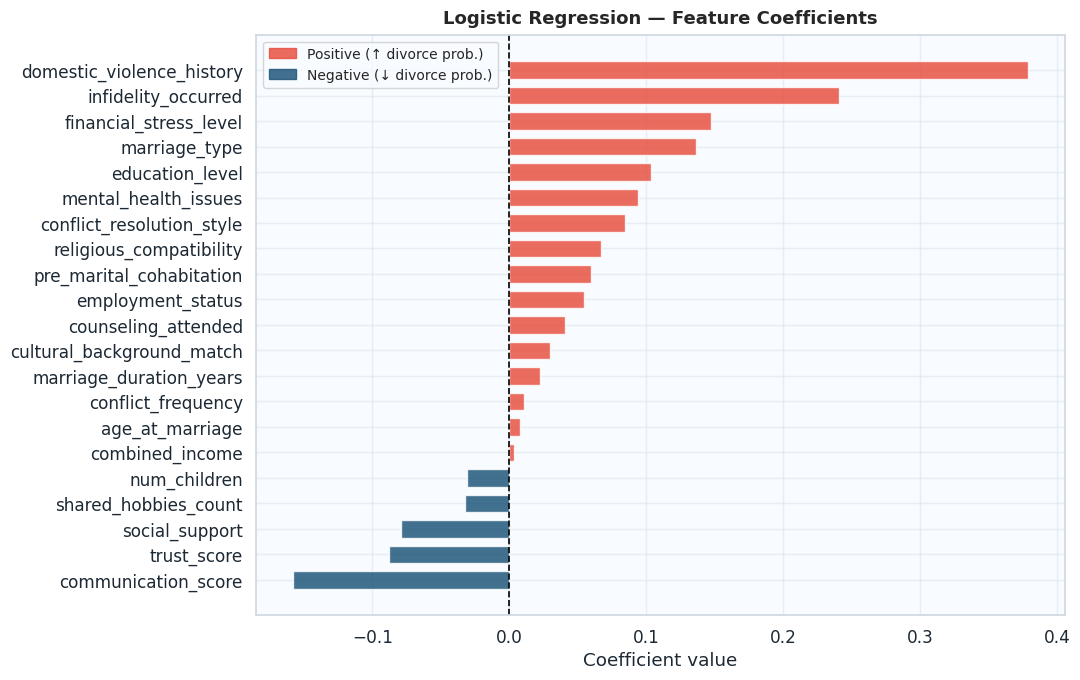

In [27]:
# ── LR coefficients plot ──────────────────────────────────────────────────────
lr_model = lr_pipeline.named_steps['classifier']
cat_names = lr_pipeline.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .get_feature_names_out(categorical_features)
all_names = list(numerical_features) + list(cat_names)

coeff_df = pd.DataFrame({'Feature': all_names, 'Coefficient': lr_model.coef_[0]})
# Aggregate dummy variables back to original feature
coeff_df['Original'] = coeff_df['Feature'].apply(
    lambda x: next((c for c in categorical_features if x.startswith(c)), x)
)
coeff_agg = coeff_df.groupby('Original')['Coefficient'].apply(
    lambda x: x.abs().mean() * np.sign(x.mean())
).reset_index().sort_values('Coefficient')
coeff_agg.columns = ['Feature','Coefficient']

fig, ax = plt.subplots(figsize=(11,7))
colors = [CORAL if v>0 else PRIMARY for v in coeff_agg['Coefficient']]
ax.barh(coeff_agg['Feature'], coeff_agg['Coefficient'],
        color=colors, alpha=0.82, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Coefficient value')
ax.set_title('Logistic Regression — Feature Coefficients', pad=8)
legend_handles = [Patch(color=CORAL, alpha=0.82, label='Positive (↑ divorce prob.)'),
                  Patch(color=PRIMARY, alpha=0.82, label='Negative (↓ divorce prob.)')]
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.savefig('fig_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


### 14.3 — Model 2: Random Forest


In [28]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=300, max_depth=None,
        min_samples_split=2, random_state=42,
    )),
])
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Not divorced','Divorced']))
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


=== Random Forest ===
              precision    recall  f1-score   support

Not divorced       0.62      0.90      0.73       602
    Divorced       0.52      0.16      0.25       398

    accuracy                           0.61      1000
   macro avg       0.57      0.53      0.49      1000
weighted avg       0.58      0.61      0.54      1000

AUC: 0.5769


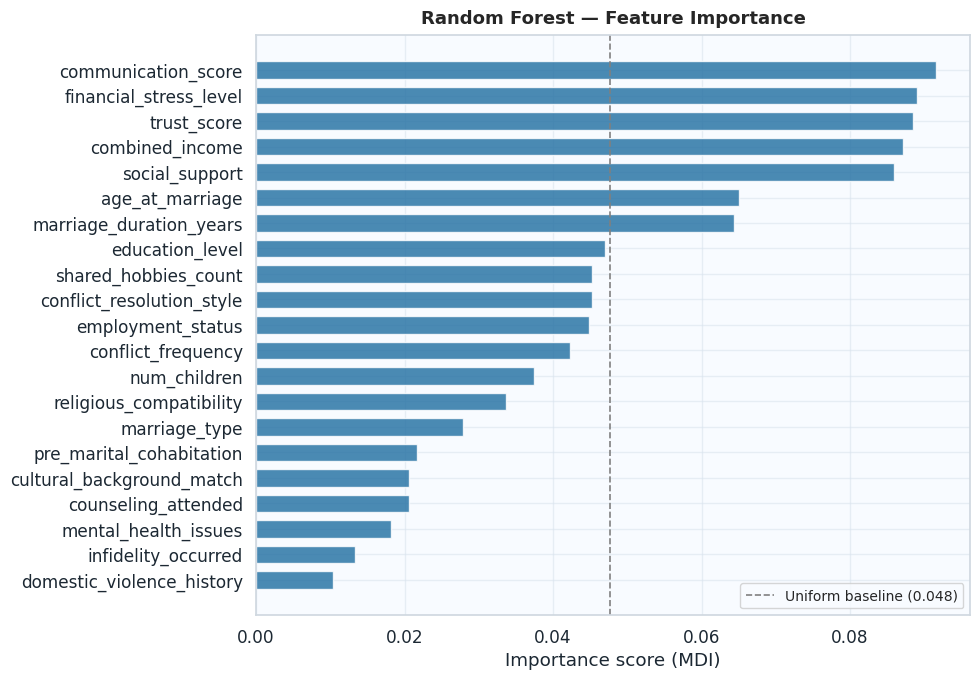

In [29]:
# ── RF feature importance ─────────────────────────────────────────────────────
rf_model = rf_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_
imp_df = pd.DataFrame({'Feature': all_names, 'Importance': importances})
imp_df['Original'] = imp_df['Feature'].apply(
    lambda x: next((c for c in categorical_features if x.startswith(c)), x)
)
imp_agg = imp_df.groupby('Original')['Importance'].sum().reset_index()
imp_agg = imp_agg.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10,7))
bars = ax.barh(imp_agg['Original'], imp_agg['Importance'],
               color=SECONDARY, alpha=0.82, edgecolor='white', height=0.7)
ax.axvline(1/len(imp_agg), color='gray', linestyle='--', linewidth=1.2,
           label=f'Uniform baseline ({1/len(imp_agg):.3f})')
ax.set_xlabel('Importance score (MDI)')
ax.set_title('Random Forest — Feature Importance', pad=8)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 14.4 — Model 3: XGBoost

In [30]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', verbosity=0,
    )),
])
xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Not divorced','Divorced']))
print(f"AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


=== XGBoost ===
              precision    recall  f1-score   support

Not divorced       0.62      0.81      0.70       602
    Divorced       0.46      0.25      0.32       398

    accuracy                           0.59      1000
   macro avg       0.54      0.53      0.51      1000
weighted avg       0.56      0.59      0.55      1000

AUC: 0.5746


### 14.5 — Model Comparison

In [31]:
# ── Build summary table ───────────────────────────────────────────────────────
models_eval = {
    'Logistic Regression': (y_pred_lr,  y_prob_lr),
    'Random Forest':        (y_pred_rf,  y_prob_rf),
    'XGBoost':              (y_pred_xgb, y_prob_xgb),
}

rows = []
for name, (y_pred, y_prob) in models_eval.items():
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1-Score':  round(f1_score(y_test, y_pred),        4),
        'AUC':       round(roc_auc_score(y_test, y_prob),   4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print("=== Model Comparison ===")
print(summary_df.to_string())


=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score     AUC
Model                                                             
Logistic Regression     0.612     0.5357  0.1884    0.2788  0.5873
Random Forest           0.607     0.5200  0.1633    0.2486  0.5769
XGBoost                 0.587     0.4648  0.2487    0.3241  0.5746


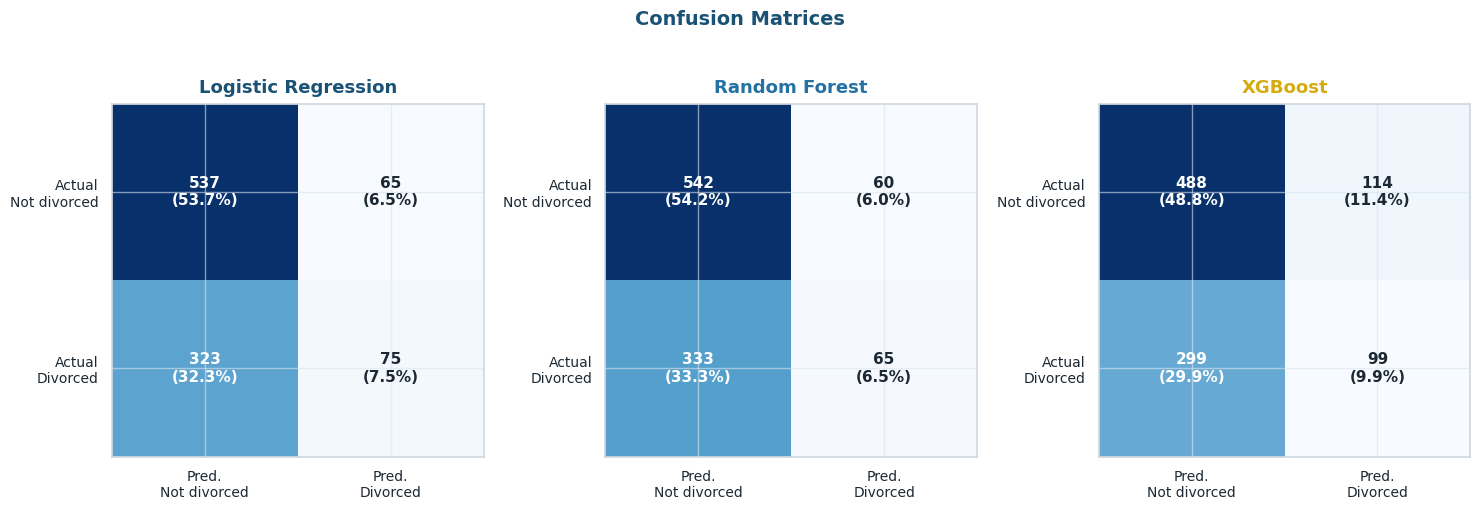

In [32]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', color=PRIMARY, y=1.02)

model_colors_list = [PRIMARY, SECONDARY, AMBER]
for ax, (name, (y_pred, _)), color in zip(axes, models_eval.items(), model_colors_list):
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred.\nNot divorced','Pred.\nDivorced'], fontsize=10)
    ax.set_yticklabels(['Actual\nNot divorced','Actual\nDivorced'], fontsize=10)
    for i in range(2):
        for j in range(2):
            v = cm[i,j]
            ax.text(j, i, f'{v}\n({v/cm.sum()*100:.1f}%)',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if v > cm.max()*0.5 else '#1C2833')
    ax.set_title(name, pad=8, color=color)

plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


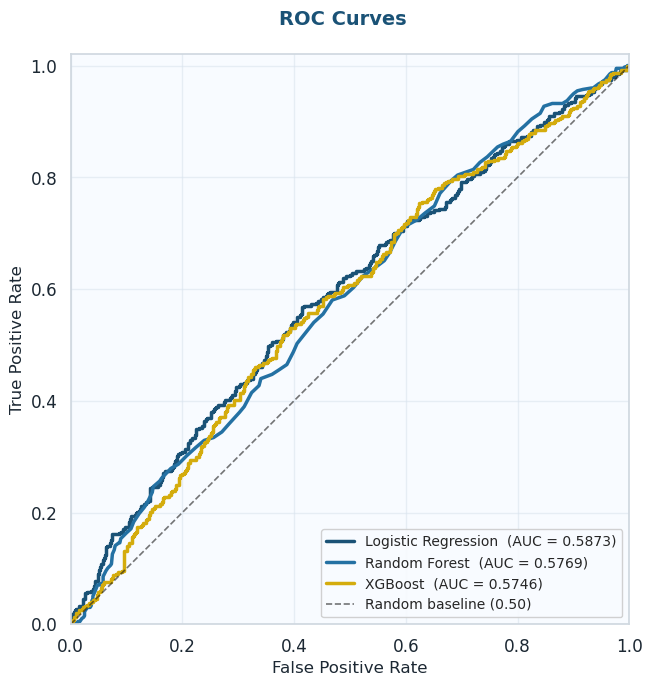

In [34]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle('ROC Curves', fontsize=14, fontweight='bold', color=PRIMARY)

for (name, (_, y_prob)), color in zip(models_eval.items(), model_colors_list):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val      = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=1.2, alpha=0.6, label='Random baseline (0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


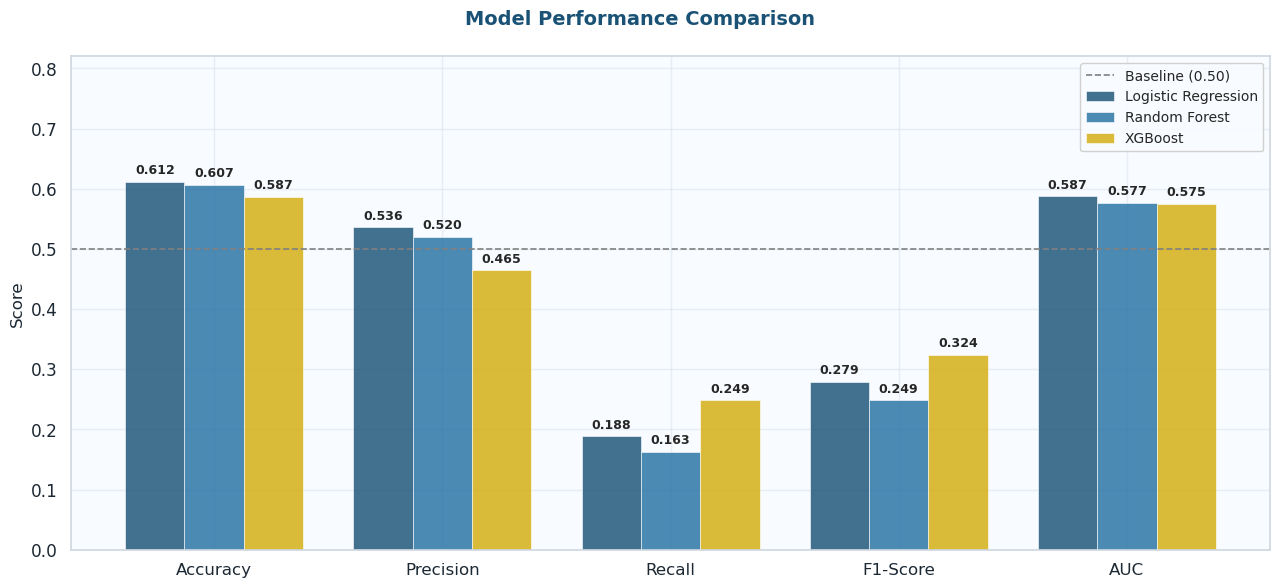

In [42]:
# ── Metrics comparison bar chart ──────────────────────────────────────────────
metric_names_plot = ['Accuracy','Precision','Recall','F1-Score','AUC']
metric_keys_plot  = ['Accuracy','Precision','Recall','F1-Score','AUC']
x     = np.arange(len(metric_names_plot))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', color=PRIMARY)

for i, (model_name, row) in enumerate(zip(summary_df.index, summary_df.values)):
    color = model_colors_list[i]
    vals = row
    bars = ax.bar(x + (i-1)*width, vals, width, color=color,
                  alpha=0.82, edgecolor='white', linewidth=0.5, label=model_name)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Baseline (0.50)')
ax.set_xticks(x); ax.set_xticklabels(metric_names_plot, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 0.82)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.6 — Signal Diagnosis


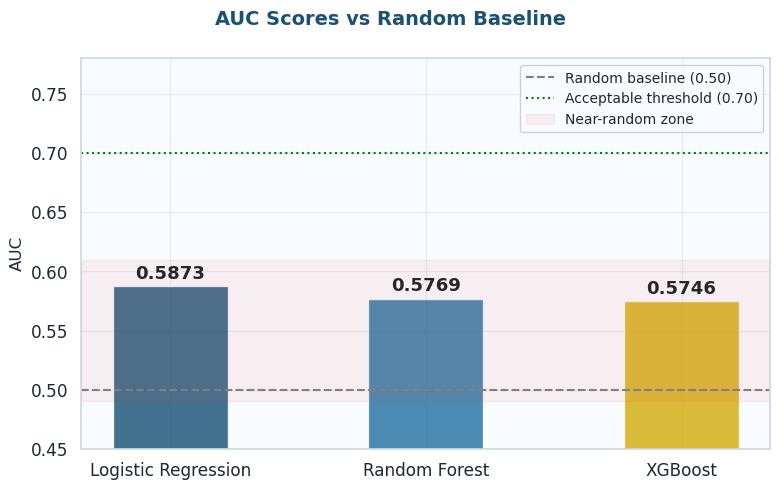


=== SIGNAL DIAGNOSIS ===
Best AUC achieved : 0.5873
Random baseline   : 0.5000
Gap above random  : 0.0873

All three models operate within the near-random zone (AUC 0.57–0.59).
This is not a modelling failure — it reflects the absence of genuine
predictive signal in the dataset's 21 cross-sectional features.
Conclusion: the dataset is insufficient for reliable divorce prediction.


In [37]:
# ── AUC near-random visualisation ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('AUC Scores vs Random Baseline', fontsize=14, fontweight='bold', color=PRIMARY)

aucs   = [summary_df.loc[m,'AUC'] for m in summary_df.index]
bars   = ax.bar(summary_df.index, aucs, color=model_colors_list,
                alpha=0.82, edgecolor='white', width=0.45)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{v:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.axhline(0.50, color='gray',  linestyle='--', linewidth=1.5, label='Random baseline (0.50)')
ax.axhline(0.70, color='green', linestyle=':',  linewidth=1.5, label='Acceptable threshold (0.70)')
ax.axhspan(0.49, 0.61, alpha=0.07, color=CORAL, label='Near-random zone')

ax.set_ylabel('AUC', fontsize=12); ax.set_ylim(0.45, 0.78)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_auc_nearrandom.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print diagnosis ───────────────────────────────────────────────────────────
print("\n=== SIGNAL DIAGNOSIS ===")
print(f"Best AUC achieved : {max(aucs):.4f}")
print(f"Random baseline   : 0.5000")
print(f"Gap above random  : {max(aucs)-0.5:.4f}")
print()
print("All three models operate within the near-random zone (AUC 0.57–0.59).")
print("This is not a modelling failure — it reflects the absence of genuine")
print("predictive signal in the dataset's 21 cross-sectional features.")
print("Conclusion: the dataset is insufficient for reliable divorce prediction.")
